# Estrategia 1 — EfficientNet B0–B7 + NAS en el clasificador

In [ ]:
# 1. Montar Drive y clonar/actualizar repo
from google.colab import drive
drive.mount('/content/drive')

import os
repo_path = '/content/darts-cards'
if not os.path.exists(repo_path):
    !git clone https://github.com/javiergarciaduran/darts-cards.git {repo_path}
else:
    !git -C {repo_path} pull
%cd {repo_path}

Mounted at /content/drive
Cloning into '/content/darts-cards'...
remote: Enumerating objects: 235, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 235 (delta 63), reused 86 (delta 45), pack-reused 110 (from 1)
Receiving objects: 100% (235/235), 11.81 MiB | 36.30 MiB/s, done.
Resolving deltas: 100% (107/107), done.
/content/darts-cards


In [ ]:
# 2. Dependencias
!pip install -q torchvision
!pip install -q scikit-learn matplotlib

In [ ]:
# 3. Fix encoding
!iconv -f UTF-16 -t UTF-8 /content/darts-cards/datasets/__init__.py > temp.py && mv temp.py /content/darts-cards/datasets/__init__.py

In [ ]:
# 4. Symlink dataset
!mkdir -p ./data
!ln -sfn /content/drive/MyDrive/cards ./data/cards

# Verificar
from datasets.cards import get_cards
tr, nc = get_cards('./data/cards', input_size=224, split='train')
va, _  = get_cards('./data/cards', input_size=224, split='val')
print(f'train={len(tr)}  val={len(va)}  classes={nc}')

train=7640  val=265  classes=53


In [ ]:
# 5. Crear carpetas de salida en Drive
!mkdir -p /content/drive/MyDrive/darts_experiments/efficientnet
!mkdir -p /content/drive/MyDrive/darts_logs/efficientnet

## B0 — empezar aquí (el más ligero, ~5 min)
Ejecuta primero B0 para verificar que todo funciona. Luego escala a B1–B7.

In [ ]:
!python efficientnet_search.py \
    --backbone efficientnet_b0 \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/efficientnet \
    --epochs 50 \
    --batch_size 128 \
    --hidden 256 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/efficientnet/b0.log

In [ ]:
!python efficientnet_search.py \
    --backbone efficientnet_b4 \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/efficientnet \
    --epochs 50 \
    --batch_size 32 \
    --hidden 512 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/efficientnet/b4.log

In [ ]:
!python efficientnet_search.py \
    --backbone efficientnet_b7 \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/efficientnet \
    --epochs 50 \
    --batch_size 16 \
    --hidden 512 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/efficientnet/b7.log

## Evaluación en test set — ejecutar UNA SOLA VEZ por backbone
Cambia `BACKBONE` según el modelo que quieras evaluar.

In [ ]:
BACKBONE = 'efficientnet_b0'   # cambiar por b1, b2, b3, b4, b5, b6, b7...

!python efficientnet_evaluate.py \
    --checkpoint /content/drive/MyDrive/darts_experiments/efficientnet/{BACKBONE}_seed42/best.pth.tar \
    --data_path ./data/cards

In [ ]:
BACKBONE = 'efficientnet_b4'

!python efficientnet_evaluate.py \
    --checkpoint /content/drive/MyDrive/darts_experiments/efficientnet/{BACKBONE}_seed42/best.pth.tar \
    --data_path ./data/cards

In [ ]:
BACKBONE = 'efficientnet_b7'

!python efficientnet_evaluate.py \
    --checkpoint /content/drive/MyDrive/darts_experiments/efficientnet/{BACKBONE}_seed42/best.pth.tar \
    --data_path ./data/cards

## Comparativa Estrategia 1 vs Estrategia 2

efficientnet_b0            test_top1=64.53%  val_acc=69.06%  genotype={'op1': 'linear_relu', 'op2': 'linear'}
efficientnet_b4            test_top1=69.43%  val_acc=70.19%  genotype={'op1': 'linear_dropout', 'op2': 'linear_relu'}
efficientnet_b7            test_top1=68.68%  val_acc=68.68%  genotype={'op1': 'linear', 'op2': 'linear'}


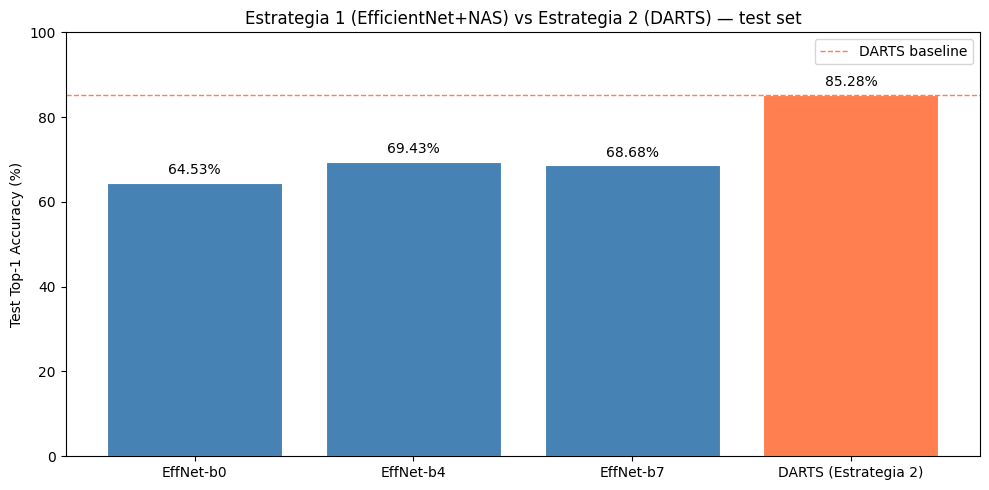

In [ ]:
import os, json
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/darts_experiments/efficientnet'
backbones = ['efficientnet_b0', 'efficientnet_b4', 'efficientnet_b7']

# Usamos test_top1 (test_results.json, generado por efficientnet_evaluate.py)
# en vez de val_acc: val_acc se usa también para actualizar los alphas de
# arquitectura durante la búsqueda, por lo que no es una métrica "limpia" de
# generalización. test_top1 nunca interviene en la optimización.
results = []
for bb in backbones:
    results_path = os.path.join(BASE, f'{bb}_seed42', 'test_results.json')
    if os.path.exists(results_path):
        with open(results_path) as f:
            r = json.load(f)
        results.append({'backbone': bb, 'test_acc': r['test_top1'], 'genotype': r['genotype']})
        print(f"{bb:25s}  test_top1={r['test_top1']:.2f}%  val_acc={r['val_acc']:.2f}%  genotype={r['genotype']}")
    else:
        print(f"{bb:25s}  — falta test_results.json (ejecuta efficientnet_evaluate.py)")

# Añadir resultado DARTS (Estrategia 2) para comparar.
# NOTA: para que la comparación sea consistente, este valor debe ser también
# una accuracy de TEST (no de validación) de la fase augment.py.
results.append({'backbone': 'DARTS (Estrategia 2)', 'test_acc': 85.28})

labels  = [r['backbone'].replace('efficientnet_', 'EffNet-') for r in results]
accs    = [r['test_acc'] for r in results]
colors  = ['steelblue'] * (len(results)-1) + ['coral']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=10)
ax.set_ylim(0, 100)
ax.set_ylabel('Test Top-1 Accuracy (%)')
ax.set_title('Estrategia 1 (EfficientNet+NAS) vs Estrategia 2 (DARTS) — test set')
ax.axhline(85.28, color='coral', linestyle='--', linewidth=1, label='DARTS baseline')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'comparison.png'), dpi=150)
plt.show()